In [1]:
# Manual Stable Diffusion sampling that uses the scheduler.step update (fixed)
# Requires: diffusers, transformers, accelerate, safetensors, torch
import torch
from diffusers import StableDiffusionPipeline
from PIL import Image
import numpy as np
import math
import os

# --- Config ---
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

prompt = "six cups on a wooden table, photorealistic"
height = 512
width = 512
num_inference_steps = 50
seed = 0
guidance_scale = 7.5
save_path = "six_cups.png"
do_cfg = True

torch.manual_seed(seed)

# --- Load pipeline and components ---
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)
pipe.safety_checker = None  # optional: skip NSFW checks if you want exact same output quickly

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

# eval mode
unet.eval()
vae.eval()
text_encoder.eval()

# --- 1) Encode prompt ---
text_inputs = tokenizer(
    prompt,
    padding="max_length",
    max_length=tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    text_embeddings = text_encoder(text_inputs.input_ids)[0]   # shape [1, seq_len, hidden_dim]

# Classifier-free guidance: unconditional + conditional embeddings
if guidance_scale > 1.0:
    uncond_input = tokenizer(
        [""] * text_inputs.input_ids.shape[0],
        padding="max_length",
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        uncond_embeddings = text_encoder(uncond_input.input_ids)[0]
    prompt_embeds_for_unet = torch.cat([uncond_embeddings, text_embeddings], dim=0)
else:
    prompt_embeds_for_unet = text_embeddings

# --- 2) Setup timesteps and latents ---
scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = scheduler.timesteps  # tensor of timesteps

# Prepare initial latents using scheduler.init_noise_sigma if available
# Many schedulers expose init_noise_sigma; fallback to 1.0 if not present
init_noise_sigma = getattr(scheduler, "init_noise_sigma", 1.0)

batch_size = 1
num_channels_latents = unet.in_channels
latent_height = height // pipe.vae_scale_factor
latent_width = width // pipe.vae_scale_factor

# Prepare latents (same as pipeline.prepare_latents)
latents = torch.randn(
    (batch_size, num_channels_latents, latent_height, latent_width),
    device=device,
    dtype=dtype,
) * init_noise_sigma

# If pipeline had pre-specified latents argument you could use that instead.

# Extra kwargs for scheduler.step (eta used for certain schedulers)
extra_step_kwargs = {}
if "eta" in scheduler.__class__.__name__.lower():
    extra_step_kwargs["eta"] = 0.0
# But better: use prepare_extra_step_kwargs from pipeline (internal helper) if available
try:
    extra_step_kwargs = pipe.prepare_extra_step_kwargs(generator=None, eta=0.0)
except Exception:
    # fallback: keep empty or minimal
    extra_step_kwargs = {}

# --- 3) Denoising loop (matching pipeline) ---
with torch.no_grad():
    for i, t in enumerate(timesteps):
        # Expand latents for classifier free guidance if needed
        latent_model_input = torch.cat([latents] * 2) if do_cfg else latents

        # Some schedulers require scaling the model input (e.g. LMSDiscreteScheduler)
        if hasattr(scheduler, "scale_model_input"):
            latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        # Predict the noise residual with UNet
        # Use the correct forward signature: sample, timestep, encoder_hidden_states=...
        # Many UNet implementations accept `timestep_cond` etc; we keep minimal.
        unet_out = unet(
            latent_model_input,
            timestep=t,
            encoder_hidden_states=prompt_embeds_for_unet,
            return_dict=False,
        )
        # unet returns tuple (sample, ...) when return_dict=False
        noise_pred = unet_out[0]

        # Guidance
        if do_cfg:
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # Use scheduler to compute previous sample
        # Many schedulers expect noise_pred, timestep, sample -> return_dict False -> [prev_sample]
        step_output = scheduler.step(noise_pred, t, latents, **extra_step_kwargs, return_dict=False)
        latents = step_output[0]  # updated latents

# --- 4) Decode latents to image ---
# stable-diffusion uses scaling factor in VAE config
latents = latents / pipe.vae.config.scaling_factor
with torch.no_grad():
    image = vae.decode(latents).sample

# postprocess: from [-1,1] to [0,255]
image = (image / 2 + 0.5).clamp(0, 1)
image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
pil = Image.fromarray(image_np)
pil.save(save_path)
print("Saved to", save_path)

from IPython.display import display
display(pil)


/home/ziseok/ziseok/2D-HCG/Image-HCG/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.29it/s]
/tmp/ipykernel_3297282/3465568859.py:77: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = unet.in_channels


Saved to six_cups.png


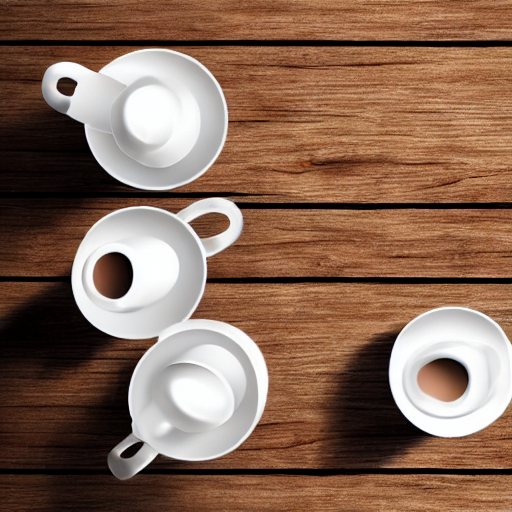

Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.06it/s]
/tmp/ipykernel_3297282/870469875.py:120: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = unet.in_channels


latent patches: [(4, 10, 20, 30), (40, 10, 56, 30), (22, 34, 38, 54)]


100%|██████████| 51/51 [00:12<00:00,  4.13it/s]


Saved to cow_horse_sheep_patches_uncond_subtract.png


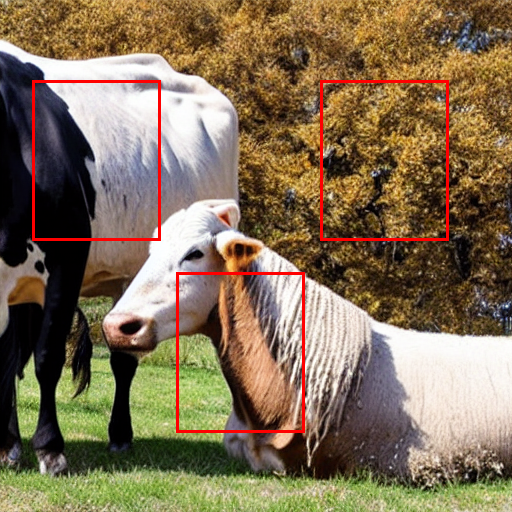

In [5]:
# patchwise_conditioned_sd_uncond_subtract.py
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from PIL import Image
import numpy as np
from tqdm import tqdm

# ---------- Config ----------
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

main_prompt = "a photo of a cow, a horse, and a sheep"
patch_prompt = "cow" # "horse", "sheep"
height = 512
width = 512
num_inference_steps = 50
seed = 0
guidance_scale_main = 7.5
guidance_scale_patch = 5.0
# save_path = "six_cups_patches_uncond_subtract.png"
save_path = "cow_horse_sheep_patches_uncond_subtract.png"
do_cfg = True  # classifier-free guidance on

torch.manual_seed(seed)

# ---------- Load pipeline & components ----------
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)
pipe.safety_checker = None

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

unet.eval()
vae.eval()
text_encoder.eval()

# ---------- Helper: stateless DDPM posterior (for patch updates) ----------
def ddpm_prev_sample_stateless(sample, noise_pred, t, alphas_cumprod):
    """
    Stateless DDPM posterior update to compute x_{t-1} from x_t (sample) and predicted epsilon.
    Works with schedulers that expose alphas_cumprod (DDPM-like).
    """
    t_index = int(t.item()) if isinstance(t, torch.Tensor) else int(t)
    device = sample.device
    dtype = sample.dtype

    alpha_bar_t = alphas_cumprod[t_index].to(device=device, dtype=dtype)
    alpha_bar_prev = alphas_cumprod[t_index - 1].to(device=device, dtype=dtype) if t_index > 0 else torch.tensor(1.0, device=device, dtype=dtype)

    alpha_t = alpha_bar_t / alpha_bar_prev
    beta_t = 1.0 - alpha_t

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
    sqrt_alpha_bar_prev = torch.sqrt(alpha_bar_prev)
    sqrt_alpha_t = torch.sqrt(alpha_t)

    # predict x0
    pred_x0 = (sample - sqrt_one_minus_alpha_bar_t * noise_pred) / (sqrt_alpha_bar_t + 1e-12)

    # posterior mean coefficients (DDPM)
    coef_x0 = (sqrt_alpha_bar_prev * beta_t) / (1.0 - alpha_bar_t + 1e-12)
    coef_xt = (sqrt_alpha_t * (1.0 - alpha_bar_prev)) / (1.0 - alpha_bar_t + 1e-12)
    mu = coef_x0 * pred_x0 + coef_xt * sample

    posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-12)
    posterior_var = posterior_var.clamp(min=1e-20)

    if t_index > 0:
        noise = torch.randn_like(sample)
        prev = mu + torch.sqrt(posterior_var) * noise
    else:
        prev = mu

    return prev

# ---------- Prepare embeddings (manual) ----------
def make_embeddings(prompt, guidance_scale, do_cfg=True):
    text_inputs = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        text_embeddings = text_encoder(text_inputs.input_ids)[0]
    if do_cfg and guidance_scale > 1.0:
        uncond_input = tokenizer(
            [""] * text_inputs.input_ids.shape[0],
            padding="max_length",
            max_length=tokenizer.model_max_length,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            uncond_embeddings = text_encoder(uncond_input.input_ids)[0]
        return torch.cat([uncond_embeddings, text_embeddings], dim=0)
    else:
        return text_embeddings

main_emb_for_unet = make_embeddings(main_prompt, guidance_scale_main, do_cfg=do_cfg)
patch_emb_for_unet = make_embeddings(patch_prompt, guidance_scale_patch, do_cfg=do_cfg)

# ---------- Timesteps & latents ----------
scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = scheduler.timesteps
if not hasattr(scheduler, "alphas_cumprod"):
    raise RuntimeError("Scheduler does not expose alphas_cumprod; ddpm stateless update may not be valid.")

alphas_cumprod = scheduler.alphas_cumprod.to(device)

init_noise_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
batch_size = 1
num_channels_latents = unet.in_channels
latent_h = height // pipe.vae_scale_factor
latent_w = width // pipe.vae_scale_factor

latents = torch.randn((batch_size, num_channels_latents, latent_h, latent_w), device=device, dtype=dtype) * init_noise_sigma

try:
    extra_step_kwargs = pipe.prepare_extra_step_kwargs(generator=None, eta=0.0)
except Exception:
    extra_step_kwargs = {}

# ---------- Define patches (image-space -> latent-space coords) ----------
patches_image = [
    (32,  80, 160, 240),
    # (176, 80, 304, 240),
    (320, 80, 448, 240),
    # (32,  272,160, 432),
    (176, 272,304, 432),
    # (320, 272,448, 432),
]

def image_to_latent_coords(box, image_size=(width, height), latent_size=(latent_w, latent_h)):
    x0, y0, x1, y1 = box
    img_w, img_h = image_size
    l_w, l_h = latent_size
    lx0 = int(round(x0 * l_w / img_w))
    ly0 = int(round(y0 * l_h / img_h))
    lx1 = int(round(x1 * l_w / img_w))
    ly1 = int(round(y1 * l_h / img_h))
    lx0 = max(0, min(lx0, l_w-1))
    lx1 = max(0, min(max(lx1, lx0+1), l_w))
    ly0 = max(0, min(ly0, l_h-1))
    ly1 = max(0, min(max(ly1, ly0+1), l_h))
    return (lx0, ly0, lx1, ly1)

patches_latent = [image_to_latent_coords(b, (width, height), (latent_w, latent_h)) for b in patches_image]
print("latent patches:", patches_latent)

# ---------- Denoising loop ----------
with torch.no_grad():
    for i, t in enumerate(tqdm(timesteps)):
        # 1) global UNet -> predict noise for whole image
        latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
        if hasattr(scheduler, "scale_model_input"):
            latent_model_input = scheduler.scale_model_input(latent_model_input, t)

        unet_out = unet(latent_model_input, timestep=t, encoder_hidden_states=main_emb_for_unet, return_dict=False)
        noise_pred_main = unet_out[0]
        if do_cfg:
            n_uncond, n_text = noise_pred_main.chunk(2)
            noise_pred_main = n_uncond + guidance_scale_main * (n_text - n_uncond)

        # compute main latents_prev using scheduler.step once (preserves scheduler state)
        step_out = scheduler.step(noise_pred_main, t, latents, **extra_step_kwargs, return_dict=False)
        latents_prev = step_out[0].to(dtype=dtype)

        # 2) per-patch processing using stateless DDPM update (no scheduler.step calls for patches)
        for (lx0, ly0, lx1, ly1) in patches_latent:
            patch = latents[:, :, ly0:ly1, lx0:lx1]
            ph = patch.shape[2]; pw = patch.shape[3]
            if ph <= 0 or pw <= 0:
                continue

            # upsample to UNet spatial (latent_h, latent_w)
            patch_upsampled = F.interpolate(patch, size=(latent_h, latent_w), mode="bilinear", align_corners=False)

            # UNet predict for patch prompt
            patch_input = torch.cat([patch_upsampled] * 2) if do_cfg else patch_upsampled
            if hasattr(scheduler, "scale_model_input"):
                patch_input_model = scheduler.scale_model_input(patch_input, t)
            else:
                patch_input_model = patch_input

            unet_out_patch = unet(patch_input_model, timestep=t, encoder_hidden_states=patch_emb_for_unet, return_dict=False)
            noise_pred_patch_all = unet_out_patch[0]

            if do_cfg:
                # split unconditional and conditional predictions
                p_uncond, p_text = noise_pred_patch_all.chunk(2)
                # guided prediction (cond)
                noise_pred_patch_guided = p_uncond + guidance_scale_patch * (p_text - p_uncond)
            else:
                noise_pred_patch_guided = noise_pred_patch_all
                p_uncond = None

            # stateless DDPM prev-sample for patch (guided)
            patch_prev_full = ddpm_prev_sample_stateless(patch_upsampled, noise_pred_patch_guided, t, alphas_cumprod)

            # if do_cfg: also compute unconditional prev-sample and subtract it later
            if do_cfg:
                patch_prev_full_uncond = ddpm_prev_sample_stateless(patch_upsampled, p_uncond, t, alphas_cumprod)
            else:
                patch_prev_full_uncond = None

            # downsample to patch size
            patch_prev_down = F.interpolate(patch_prev_full, size=(ph, pw), mode="bilinear", align_corners=False)
            if patch_prev_full_uncond is not None:
                patch_prev_down_uncond = F.interpolate(patch_prev_full_uncond, size=(ph, pw), mode="bilinear", align_corners=False)
            else:
                patch_prev_down_uncond = torch.zeros_like(patch_prev_down)

            # blend into latents_prev: existing + patch_prev_down - patch_prev_down_uncond
            existing = latents_prev[:, :, ly0:ly1, lx0:lx1]
            latents_prev[:, :, ly0:ly1, lx0:lx1] = existing + patch_prev_down - patch_prev_down_uncond

        # set for next step
        latents = latents_prev

# # ---------- Decode ----------
# latents = latents / pipe.vae.config.scaling_factor
# with torch.no_grad():
#     image = vae.decode(latents).sample

# image = (image / 2 + 0.5).clamp(0, 1)
# image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
# pil = Image.fromarray(image_np)
# pil.save(save_path)
# print("Saved to", save_path)

# ---------- Decode ----------
latents = latents / pipe.vae.config.scaling_factor
with torch.no_grad():
    image = vae.decode(latents).sample

image = (image / 2 + 0.5).clamp(0, 1)
image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
pil = Image.fromarray(image_np)

# ---------- Draw patches on top ----------
from PIL import ImageDraw

draw = ImageDraw.Draw(pil)
for (x0, y0, x1, y1) in patches_image:
    draw.rectangle([x0, y0, x1, y1], outline="red", width=3)

# Save
pil.save(save_path)
print("Saved to", save_path)

from IPython.display import display
display(pil)

Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  2.57it/s]
/tmp/ipykernel_3297282/4164547832.py:100: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = unet.in_channels
100%|██████████| 51/51 [00:01<00:00, 29.01it/s]


Saved: outputs/a_photo_of_a_cow_a_horse_and_a_sheep_baseline.png


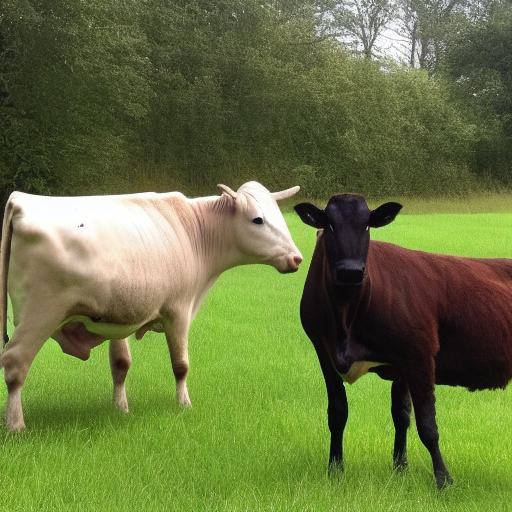

Saved: outputs/a_photo_of_a_cow_a_horse_and_a_sheep_patchwise.png


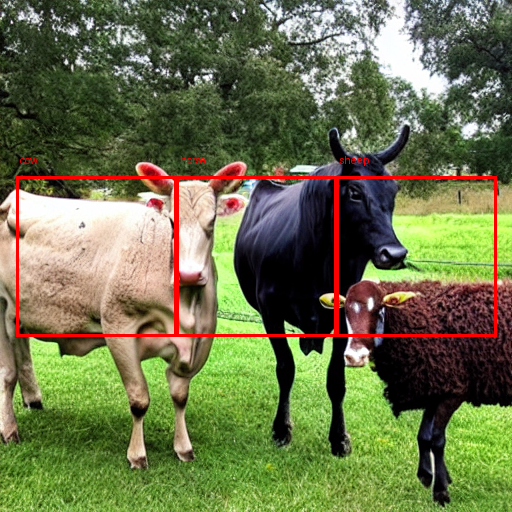

In [7]:
# patchwise_conditioned_sd_uncond_subtract.py
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from PIL import Image, ImageDraw
import numpy as np
from tqdm import tqdm
import re
import os

# ---------- Config ----------
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

main_prompt = "a photo of a cow, a horse, and a sheep"
patch_prompts = ["cow", "horse", "sheep"]  # must align with patches_image
height = 512
width = 512
num_inference_steps = 50
seed = 7
guidance_scale_main = 7.5
guidance_scale_patch = 7.5
do_cfg = True  # classifier-free guidance on

torch.manual_seed(seed)

# ---------- Load pipeline ----------
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)
pipe.safety_checker = None

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

unet.eval()
vae.eval()
text_encoder.eval()

# ---------- Helper ----------
def sanitize_filename(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "_", s.strip()).strip("_").lower()

def ddpm_prev_sample_stateless(sample, noise_pred, t, alphas_cumprod):
    """Stateless DDPM posterior update to compute x_{t-1}."""
    t_index = int(t.item()) if isinstance(t, torch.Tensor) else int(t)
    device = sample.device
    dtype = sample.dtype

    alpha_bar_t = alphas_cumprod[t_index].to(device=device, dtype=dtype)
    alpha_bar_prev = alphas_cumprod[t_index - 1].to(device=device, dtype=dtype) if t_index > 0 else torch.tensor(1.0, device=device, dtype=dtype)
    alpha_t = alpha_bar_t / alpha_bar_prev
    beta_t = 1.0 - alpha_t

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
    sqrt_alpha_bar_prev = torch.sqrt(alpha_bar_prev)
    sqrt_alpha_t = torch.sqrt(alpha_t)

    pred_x0 = (sample - sqrt_one_minus_alpha_bar_t * noise_pred) / (sqrt_alpha_bar_t + 1e-12)
    coef_x0 = (sqrt_alpha_bar_prev * beta_t) / (1.0 - alpha_bar_t + 1e-12)
    coef_xt = (sqrt_alpha_t * (1.0 - alpha_bar_prev)) / (1.0 - alpha_bar_t + 1e-12)
    mu = coef_x0 * pred_x0 + coef_xt * sample

    posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-12)
    posterior_var = posterior_var.clamp(min=1e-20)

    if t_index > 0:
        noise = torch.randn_like(sample)
        prev = mu + torch.sqrt(posterior_var) * noise
    else:
        prev = mu
    return prev

def make_embeddings(prompt, guidance_scale, do_cfg=True):
    text_inputs = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length,
                            truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        text_embeddings = text_encoder(text_inputs.input_ids)[0]
    if do_cfg and guidance_scale > 1.0:
        uncond_input = tokenizer([""] * text_inputs.input_ids.shape[0],
                                 padding="max_length", max_length=tokenizer.model_max_length,
                                 return_tensors="pt").to(device)
        with torch.no_grad():
            uncond_embeddings = text_encoder(uncond_input.input_ids)[0]
        return torch.cat([uncond_embeddings, text_embeddings], dim=0)
    else:
        return text_embeddings

# ---------- Timesteps & latents ----------
scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = scheduler.timesteps
alphas_cumprod = scheduler.alphas_cumprod.to(device)

init_noise_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
batch_size = 1
num_channels_latents = unet.in_channels
latent_h = height // pipe.vae_scale_factor
latent_w = width // pipe.vae_scale_factor

try:
    extra_step_kwargs = pipe.prepare_extra_step_kwargs(generator=None, eta=0.0)
except Exception:
    extra_step_kwargs = {}

# ---------- Patches ----------
patches_image = [
    (16, 176, 176, 336),    # patch 1
    (176, 176, 336, 336),   # patch 2
    (336, 176, 496, 336),   # patch 3
]
assert len(patch_prompts) == len(patches_image), "Number of patch prompts must equal number of patches"

def image_to_latent_coords(box, image_size=(width, height), latent_size=(latent_w, latent_h)):
    x0, y0, x1, y1 = box
    img_w, img_h = image_size
    l_w, l_h = latent_size
    lx0 = int(round(x0 * l_w / img_w))
    ly0 = int(round(y0 * l_h / img_h))
    lx1 = int(round(x1 * l_w / img_w))
    ly1 = int(round(y1 * l_h / img_h))
    lx0 = max(0, min(lx0, l_w-1))
    lx1 = max(0, min(max(lx1, lx0+1), l_w))
    ly0 = max(0, min(ly0, l_h-1))
    ly1 = max(0, min(max(ly1, ly0+1), l_h))
    return (lx0, ly0, lx1, ly1)

patches_latent = [image_to_latent_coords(b, (width, height), (latent_w, latent_h)) for b in patches_image]

# ---------- Embeddings ----------
main_emb_for_unet = make_embeddings(main_prompt, guidance_scale_main, do_cfg=do_cfg)
patch_embs_for_unet = [make_embeddings(p, guidance_scale_patch, do_cfg=do_cfg) for p in patch_prompts]

# ---------- Run one pass (helper) ----------
def run_denoising(latents, use_patches=True):
    with torch.no_grad():
        for i, t in enumerate(tqdm(timesteps)):
            latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
            if hasattr(scheduler, "scale_model_input"):
                latent_model_input = scheduler.scale_model_input(latent_model_input, t)

            unet_out = unet(latent_model_input, timestep=t, encoder_hidden_states=main_emb_for_unet, return_dict=False)
            noise_pred_main = unet_out[0]
            if do_cfg:
                n_uncond, n_text = noise_pred_main.chunk(2)
                noise_pred_main = n_uncond + guidance_scale_main * (n_text - n_uncond)

            step_out = scheduler.step(noise_pred_main, t, latents, **extra_step_kwargs, return_dict=False)
            latents_prev = step_out[0].to(dtype=dtype)

            if use_patches:
                for (lx0, ly0, lx1, ly1), patch_emb in zip(patches_latent, patch_embs_for_unet):
                    patch = latents[:, :, ly0:ly1, lx0:lx1]
                    ph, pw = patch.shape[2:]
                    if ph <= 0 or pw <= 0: continue

                    patch_upsampled = F.interpolate(patch, size=(latent_h, latent_w), mode="bilinear", align_corners=False)
                    patch_input = torch.cat([patch_upsampled] * 2) if do_cfg else patch_upsampled
                    if hasattr(scheduler, "scale_model_input"):
                        patch_input_model = scheduler.scale_model_input(patch_input, t)
                    else:
                        patch_input_model = patch_input

                    unet_out_patch = unet(patch_input_model, timestep=t, encoder_hidden_states=patch_emb, return_dict=False)
                    noise_pred_patch_all = unet_out_patch[0]

                    if do_cfg:
                        p_uncond, p_text = noise_pred_patch_all.chunk(2)
                        noise_pred_patch_guided = p_uncond + guidance_scale_patch * (p_text - p_uncond)
                    else:
                        noise_pred_patch_guided = noise_pred_patch_all
                        p_uncond = None

                    patch_prev_full = ddpm_prev_sample_stateless(patch_upsampled, noise_pred_patch_guided, t, alphas_cumprod)

                    if do_cfg:
                        patch_prev_full_uncond = ddpm_prev_sample_stateless(patch_upsampled, p_uncond, t, alphas_cumprod)
                    else:
                        patch_prev_full_uncond = torch.zeros_like(patch_prev_full)

                    patch_prev_down = F.interpolate(patch_prev_full, size=(ph, pw), mode="bilinear", align_corners=False)
                    patch_prev_down_uncond = F.interpolate(patch_prev_full_uncond, size=(ph, pw), mode="bilinear", align_corners=False)

                    existing = latents_prev[:, :, ly0:ly1, lx0:lx1]
                    latents_prev[:, :, ly0:ly1, lx0:lx1] = existing + patch_prev_down - patch_prev_down_uncond

            latents = latents_prev
    return latents

# ---------- Run baseline and patchwise ----------
init_latents = torch.randn((batch_size, num_channels_latents, latent_h, latent_w),
                           device=device, dtype=dtype) * init_noise_sigma

latents_patch = run_denoising(init_latents.clone(), use_patches=True)
latents_base = run_denoising(init_latents.clone(), use_patches=False)

# ---------- Decode and save ----------
def decode_and_save(latents, filename, draw_patches=True):
    latents = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0, 1)
    image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
    pil = Image.fromarray(image_np)

    if draw_patches:
        draw = ImageDraw.Draw(pil)
        # Try to load a font (optional, falls back to default if not found)

        for (box, label) in zip(patches_image, patch_prompts):
            x0, y0, x1, y1 = box
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            # Draw label slightly above top-left corner
            draw.text((x0 + 4, y0 - 22), label, fill="red")

    pil.save(filename)
    print("Saved:", filename)

    from IPython.display import display
    display(pil)

base_name = sanitize_filename(main_prompt)
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

decode_and_save(latents_base, os.path.join(out_dir, f"{base_name}_baseline.png"), draw_patches=False)
decode_and_save(latents_patch, os.path.join(out_dir, f"{base_name}_patchwise.png"), draw_patches=True)




Loading pipeline components...: 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
/tmp/ipykernel_3297282/558084678.py:100: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = unet.in_channels
100%|██████████| 51/51 [00:03<00:00, 16.57it/s]


Saved: outputs/a_photo_of_a_man_woman_and_dog_baseline.png


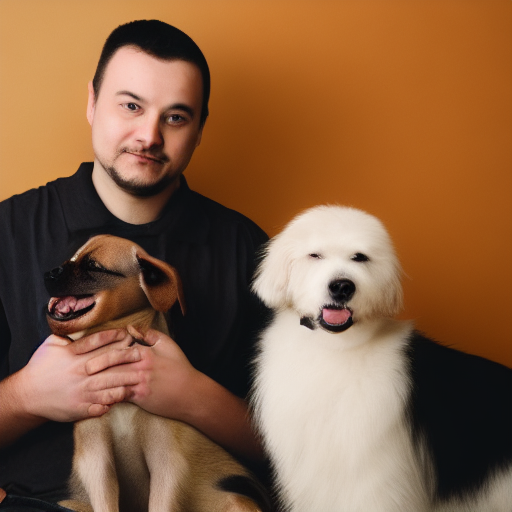

Saved: outputs/a_photo_of_a_man_woman_and_dog_patchwise.png


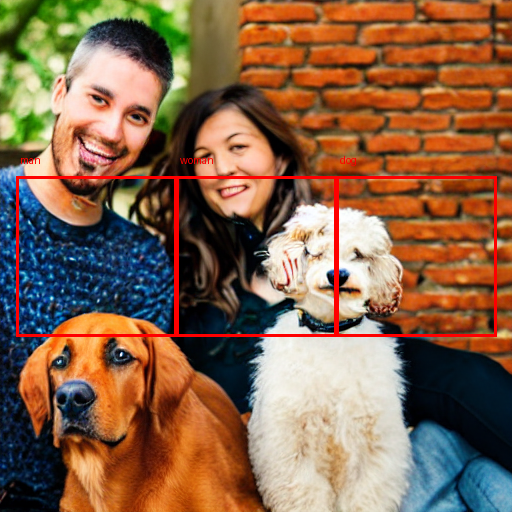

In [8]:
# patchwise_conditioned_sd_uncond_subtract.py
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from PIL import Image, ImageDraw
import numpy as np
from tqdm import tqdm
import re
import os

# ---------- Config ----------
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

main_prompt = "a photo of a man, woman, and dog"
patch_prompts = ["man", "woman", "dog"]  # must align with patches_image
height = 512
width = 512
num_inference_steps = 50
seed = 10
guidance_scale_main = 7.5
guidance_scale_patch = 7.5
do_cfg = True  # classifier-free guidance on

torch.manual_seed(seed)

# ---------- Load pipeline ----------
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)
pipe.safety_checker = None

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

unet.eval()
vae.eval()
text_encoder.eval()

# ---------- Helper ----------
def sanitize_filename(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "_", s.strip()).strip("_").lower()

def ddpm_prev_sample_stateless(sample, noise_pred, t, alphas_cumprod):
    """Stateless DDPM posterior update to compute x_{t-1}."""
    t_index = int(t.item()) if isinstance(t, torch.Tensor) else int(t)
    device = sample.device
    dtype = sample.dtype

    alpha_bar_t = alphas_cumprod[t_index].to(device=device, dtype=dtype)
    alpha_bar_prev = alphas_cumprod[t_index - 1].to(device=device, dtype=dtype) if t_index > 0 else torch.tensor(1.0, device=device, dtype=dtype)
    alpha_t = alpha_bar_t / alpha_bar_prev
    beta_t = 1.0 - alpha_t

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
    sqrt_alpha_bar_prev = torch.sqrt(alpha_bar_prev)
    sqrt_alpha_t = torch.sqrt(alpha_t)

    pred_x0 = (sample - sqrt_one_minus_alpha_bar_t * noise_pred) / (sqrt_alpha_bar_t + 1e-12)
    coef_x0 = (sqrt_alpha_bar_prev * beta_t) / (1.0 - alpha_bar_t + 1e-12)
    coef_xt = (sqrt_alpha_t * (1.0 - alpha_bar_prev)) / (1.0 - alpha_bar_t + 1e-12)
    mu = coef_x0 * pred_x0 + coef_xt * sample

    posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-12)
    posterior_var = posterior_var.clamp(min=1e-20)

    if t_index > 0:
        noise = torch.randn_like(sample)
        prev = mu + torch.sqrt(posterior_var) * noise
    else:
        prev = mu
    return prev

def make_embeddings(prompt, guidance_scale, do_cfg=True):
    text_inputs = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length,
                            truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        text_embeddings = text_encoder(text_inputs.input_ids)[0]
    if do_cfg and guidance_scale > 1.0:
        uncond_input = tokenizer([""] * text_inputs.input_ids.shape[0],
                                 padding="max_length", max_length=tokenizer.model_max_length,
                                 return_tensors="pt").to(device)
        with torch.no_grad():
            uncond_embeddings = text_encoder(uncond_input.input_ids)[0]
        return torch.cat([uncond_embeddings, text_embeddings], dim=0)
    else:
        return text_embeddings

# ---------- Timesteps & latents ----------
scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = scheduler.timesteps
alphas_cumprod = scheduler.alphas_cumprod.to(device)

init_noise_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
batch_size = 1
num_channels_latents = unet.in_channels
latent_h = height // pipe.vae_scale_factor
latent_w = width // pipe.vae_scale_factor

try:
    extra_step_kwargs = pipe.prepare_extra_step_kwargs(generator=None, eta=0.0)
except Exception:
    extra_step_kwargs = {}

# ---------- Patches ----------
patches_image = [
    (16, 176, 176, 336),    # patch 1
    (176, 176, 336, 336),   # patch 2
    (336, 176, 496, 336),   # patch 3
]
assert len(patch_prompts) == len(patches_image), "Number of patch prompts must equal number of patches"

def image_to_latent_coords(box, image_size=(width, height), latent_size=(latent_w, latent_h)):
    x0, y0, x1, y1 = box
    img_w, img_h = image_size
    l_w, l_h = latent_size
    lx0 = int(round(x0 * l_w / img_w))
    ly0 = int(round(y0 * l_h / img_h))
    lx1 = int(round(x1 * l_w / img_w))
    ly1 = int(round(y1 * l_h / img_h))
    lx0 = max(0, min(lx0, l_w-1))
    lx1 = max(0, min(max(lx1, lx0+1), l_w))
    ly0 = max(0, min(ly0, l_h-1))
    ly1 = max(0, min(max(ly1, ly0+1), l_h))
    return (lx0, ly0, lx1, ly1)

patches_latent = [image_to_latent_coords(b, (width, height), (latent_w, latent_h)) for b in patches_image]

# ---------- Embeddings ----------
main_emb_for_unet = make_embeddings(main_prompt, guidance_scale_main, do_cfg=do_cfg)
patch_embs_for_unet = [make_embeddings(p, guidance_scale_patch, do_cfg=do_cfg) for p in patch_prompts]

# ---------- Run one pass (helper) ----------
def run_denoising(latents, use_patches=True):
    with torch.no_grad():
        for i, t in enumerate(tqdm(timesteps)):
            latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
            if hasattr(scheduler, "scale_model_input"):
                latent_model_input = scheduler.scale_model_input(latent_model_input, t)

            unet_out = unet(latent_model_input, timestep=t, encoder_hidden_states=main_emb_for_unet, return_dict=False)
            noise_pred_main = unet_out[0]
            if do_cfg:
                n_uncond, n_text = noise_pred_main.chunk(2)
                noise_pred_main = n_uncond + guidance_scale_main * (n_text - n_uncond)

            step_out = scheduler.step(noise_pred_main, t, latents, **extra_step_kwargs, return_dict=False)
            latents_prev = step_out[0].to(dtype=dtype)

            if use_patches:
                for (lx0, ly0, lx1, ly1), patch_emb in zip(patches_latent, patch_embs_for_unet):
                    patch = latents[:, :, ly0:ly1, lx0:lx1]
                    ph, pw = patch.shape[2:]
                    if ph <= 0 or pw <= 0: continue

                    patch_upsampled = F.interpolate(patch, size=(latent_h, latent_w), mode="bilinear", align_corners=False)
                    patch_input = torch.cat([patch_upsampled] * 2) if do_cfg else patch_upsampled
                    if hasattr(scheduler, "scale_model_input"):
                        patch_input_model = scheduler.scale_model_input(patch_input, t)
                    else:
                        patch_input_model = patch_input

                    unet_out_patch = unet(patch_input_model, timestep=t, encoder_hidden_states=patch_emb, return_dict=False)
                    noise_pred_patch_all = unet_out_patch[0]

                    if do_cfg:
                        p_uncond, p_text = noise_pred_patch_all.chunk(2)
                        noise_pred_patch_guided = p_uncond + guidance_scale_patch * (p_text - p_uncond)
                    else:
                        noise_pred_patch_guided = noise_pred_patch_all
                        p_uncond = None

                    patch_prev_full = ddpm_prev_sample_stateless(patch_upsampled, noise_pred_patch_guided, t, alphas_cumprod)

                    if do_cfg:
                        patch_prev_full_uncond = ddpm_prev_sample_stateless(patch_upsampled, p_uncond, t, alphas_cumprod)
                    else:
                        patch_prev_full_uncond = torch.zeros_like(patch_prev_full)

                    patch_prev_down = F.interpolate(patch_prev_full, size=(ph, pw), mode="bilinear", align_corners=False)
                    patch_prev_down_uncond = F.interpolate(patch_prev_full_uncond, size=(ph, pw), mode="bilinear", align_corners=False)

                    existing = latents_prev[:, :, ly0:ly1, lx0:lx1]
                    latents_prev[:, :, ly0:ly1, lx0:lx1] = existing + patch_prev_down - patch_prev_down_uncond

            latents = latents_prev
    return latents

# ---------- Run baseline and patchwise ----------
init_latents = torch.randn((batch_size, num_channels_latents, latent_h, latent_w),
                           device=device, dtype=dtype) * init_noise_sigma

latents_patch = run_denoising(init_latents.clone(), use_patches=True)
latents_base = run_denoising(init_latents.clone(), use_patches=False)

# ---------- Decode and save ----------
def decode_and_save(latents, filename, draw_patches=True):
    latents = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0, 1)
    image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
    pil = Image.fromarray(image_np)

    if draw_patches:
        draw = ImageDraw.Draw(pil)
        # Try to load a font (optional, falls back to default if not found)

        for (box, label) in zip(patches_image, patch_prompts):
            x0, y0, x1, y1 = box
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            # Draw label slightly above top-left corner
            draw.text((x0 + 4, y0 - 22), label, fill="red")

    pil.save(filename)
    print("Saved:", filename)

    from IPython.display import display
    display(pil)

base_name = sanitize_filename(main_prompt)
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

decode_and_save(latents_base, os.path.join(out_dir, f"{base_name}_baseline.png"), draw_patches=False)
decode_and_save(latents_patch, os.path.join(out_dir, f"{base_name}_patchwise.png"), draw_patches=True)


Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
/tmp/ipykernel_3297282/3239022423.py:100: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = unet.in_channels
100%|██████████| 51/51 [00:03<00:00, 16.42it/s]


Saved: outputs/a_photo_of_a_six_puppies_baseline.png


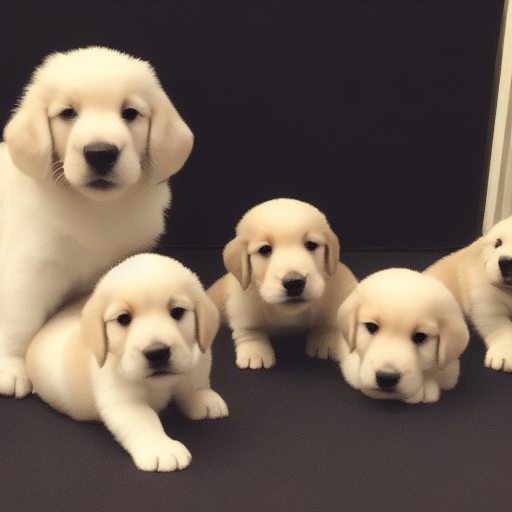

Saved: outputs/a_photo_of_a_six_puppies_patchwise.png


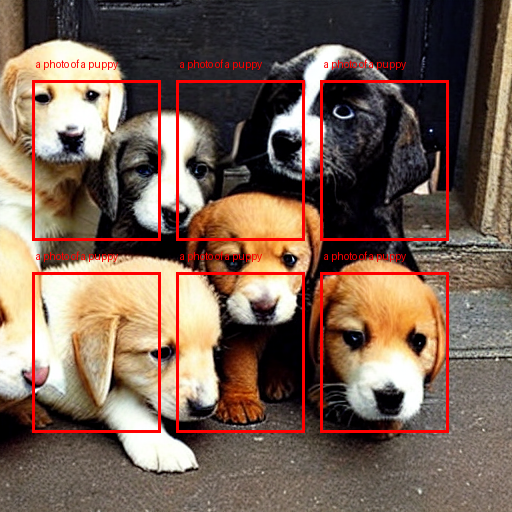

In [21]:
# patchwise_conditioned_sd_uncond_subtract.py
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from PIL import Image, ImageDraw
import numpy as np
from tqdm import tqdm
import re
import os

# ---------- Config ----------
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

main_prompt = "a photo of a six puppies"
patch_prompts = ["a photo of a puppy"] * 6  # must align with patches_image
height = 512
width = 512
num_inference_steps = 50
seed = 3 #2,4
guidance_scale_main = 7.5
guidance_scale_patch = 7.5
do_cfg = True  # classifier-free guidance on

torch.manual_seed(seed)

# ---------- Load pipeline ----------
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)
pipe.safety_checker = None

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

unet.eval()
vae.eval()
text_encoder.eval()

# ---------- Helper ----------
def sanitize_filename(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "_", s.strip()).strip("_").lower()

def ddpm_prev_sample_stateless(sample, noise_pred, t, alphas_cumprod):
    """Stateless DDPM posterior update to compute x_{t-1}."""
    t_index = int(t.item()) if isinstance(t, torch.Tensor) else int(t)
    device = sample.device
    dtype = sample.dtype

    alpha_bar_t = alphas_cumprod[t_index].to(device=device, dtype=dtype)
    alpha_bar_prev = alphas_cumprod[t_index - 1].to(device=device, dtype=dtype) if t_index > 0 else torch.tensor(1.0, device=device, dtype=dtype)
    alpha_t = alpha_bar_t / alpha_bar_prev
    beta_t = 1.0 - alpha_t

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
    sqrt_alpha_bar_prev = torch.sqrt(alpha_bar_prev)
    sqrt_alpha_t = torch.sqrt(alpha_t)

    pred_x0 = (sample - sqrt_one_minus_alpha_bar_t * noise_pred) / (sqrt_alpha_bar_t + 1e-12)
    coef_x0 = (sqrt_alpha_bar_prev * beta_t) / (1.0 - alpha_bar_t + 1e-12)
    coef_xt = (sqrt_alpha_t * (1.0 - alpha_bar_prev)) / (1.0 - alpha_bar_t + 1e-12)
    mu = coef_x0 * pred_x0 + coef_xt * sample

    posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-12)
    posterior_var = posterior_var.clamp(min=1e-20)

    if t_index > 0:
        noise = torch.randn_like(sample)
        prev = mu + torch.sqrt(posterior_var) * noise
    else:
        prev = mu
    return prev

def make_embeddings(prompt, guidance_scale, do_cfg=True):
    text_inputs = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length,
                            truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        text_embeddings = text_encoder(text_inputs.input_ids)[0]
    if do_cfg and guidance_scale > 1.0:
        uncond_input = tokenizer([""] * text_inputs.input_ids.shape[0],
                                 padding="max_length", max_length=tokenizer.model_max_length,
                                 return_tensors="pt").to(device)
        with torch.no_grad():
            uncond_embeddings = text_encoder(uncond_input.input_ids)[0]
        return torch.cat([uncond_embeddings, text_embeddings], dim=0)
    else:
        return text_embeddings

# ---------- Timesteps & latents ----------
scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = scheduler.timesteps
alphas_cumprod = scheduler.alphas_cumprod.to(device)

init_noise_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
batch_size = 1
num_channels_latents = unet.in_channels
latent_h = height // pipe.vae_scale_factor
latent_w = width // pipe.vae_scale_factor

try:
    extra_step_kwargs = pipe.prepare_extra_step_kwargs(generator=None, eta=0.0)
except Exception:
    extra_step_kwargs = {}

# ---------- Patches ----------
patches_image = [
    (32,  80, 160, 240),   # patch 1
    (176, 80, 304, 240),   # patch 2
    (320, 80, 448, 240),   # patch 3
    (32,  272,160, 432),   # patch 4
    (176, 272,304, 432),   # patch 5
    (320, 272,448, 432),   # patch 6
]
assert len(patch_prompts) == len(patches_image), "Number of patch prompts must equal number of patches"

def image_to_latent_coords(box, image_size=(width, height), latent_size=(latent_w, latent_h)):
    x0, y0, x1, y1 = box
    img_w, img_h = image_size
    l_w, l_h = latent_size
    lx0 = int(round(x0 * l_w / img_w))
    ly0 = int(round(y0 * l_h / img_h))
    lx1 = int(round(x1 * l_w / img_w))
    ly1 = int(round(y1 * l_h / img_h))
    lx0 = max(0, min(lx0, l_w-1))
    lx1 = max(0, min(max(lx1, lx0+1), l_w))
    ly0 = max(0, min(ly0, l_h-1))
    ly1 = max(0, min(max(ly1, ly0+1), l_h))
    return (lx0, ly0, lx1, ly1)

patches_latent = [image_to_latent_coords(b, (width, height), (latent_w, latent_h)) for b in patches_image]

# ---------- Embeddings ----------
main_emb_for_unet = make_embeddings(main_prompt, guidance_scale_main, do_cfg=do_cfg)
patch_embs_for_unet = [make_embeddings(p, guidance_scale_patch, do_cfg=do_cfg) for p in patch_prompts]

# ---------- Run one pass (helper) ----------
def run_denoising(latents, use_patches=True):
    with torch.no_grad():
        for i, t in enumerate(tqdm(timesteps)):
            latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
            if hasattr(scheduler, "scale_model_input"):
                latent_model_input = scheduler.scale_model_input(latent_model_input, t)

            unet_out = unet(latent_model_input, timestep=t, encoder_hidden_states=main_emb_for_unet, return_dict=False)
            noise_pred_main = unet_out[0]
            if do_cfg:
                n_uncond, n_text = noise_pred_main.chunk(2)
                noise_pred_main = n_uncond + guidance_scale_main * (n_text - n_uncond)

            step_out = scheduler.step(noise_pred_main, t, latents, **extra_step_kwargs, return_dict=False)
            latents_prev = step_out[0].to(dtype=dtype)

            if use_patches:
                for (lx0, ly0, lx1, ly1), patch_emb in zip(patches_latent, patch_embs_for_unet):
                    patch = latents[:, :, ly0:ly1, lx0:lx1]
                    ph, pw = patch.shape[2:]
                    if ph <= 0 or pw <= 0: continue

                    patch_upsampled = F.interpolate(patch, size=(latent_h, latent_w), mode="bilinear", align_corners=False)
                    patch_input = torch.cat([patch_upsampled] * 2) if do_cfg else patch_upsampled
                    if hasattr(scheduler, "scale_model_input"):
                        patch_input_model = scheduler.scale_model_input(patch_input, t)
                    else:
                        patch_input_model = patch_input

                    unet_out_patch = unet(patch_input_model, timestep=t, encoder_hidden_states=patch_emb, return_dict=False)
                    noise_pred_patch_all = unet_out_patch[0]

                    if do_cfg:
                        p_uncond, p_text = noise_pred_patch_all.chunk(2)
                        noise_pred_patch_guided = p_uncond + guidance_scale_patch * (p_text - p_uncond)
                    else:
                        noise_pred_patch_guided = noise_pred_patch_all
                        p_uncond = None

                    patch_prev_full = ddpm_prev_sample_stateless(patch_upsampled, noise_pred_patch_guided, t, alphas_cumprod)

                    if do_cfg:
                        patch_prev_full_uncond = ddpm_prev_sample_stateless(patch_upsampled, p_uncond, t, alphas_cumprod)
                    else:
                        patch_prev_full_uncond = torch.zeros_like(patch_prev_full)

                    patch_prev_down = F.interpolate(patch_prev_full, size=(ph, pw), mode="bilinear", align_corners=False)
                    patch_prev_down_uncond = F.interpolate(patch_prev_full_uncond, size=(ph, pw), mode="bilinear", align_corners=False)

                    existing = latents_prev[:, :, ly0:ly1, lx0:lx1]
                    latents_prev[:, :, ly0:ly1, lx0:lx1] = existing + patch_prev_down - patch_prev_down_uncond

            latents = latents_prev
    return latents

# ---------- Run baseline and patchwise ----------
init_latents = torch.randn((batch_size, num_channels_latents, latent_h, latent_w),
                           device=device, dtype=dtype) * init_noise_sigma

latents_patch = run_denoising(init_latents.clone(), use_patches=True)
latents_base = run_denoising(init_latents.clone(), use_patches=False)

# ---------- Decode and save ----------
def decode_and_save(latents, filename, draw_patches=True):
    latents = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0, 1)
    image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
    pil = Image.fromarray(image_np)

    if draw_patches:
        draw = ImageDraw.Draw(pil)
        # Try to load a font (optional, falls back to default if not found)

        for (box, label) in zip(patches_image, patch_prompts):
            x0, y0, x1, y1 = box
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            # Draw label slightly above top-left corner
            draw.text((x0 + 4, y0 - 22), label, fill="red")

    pil.save(filename)
    print("Saved:", filename)

    from IPython.display import display
    display(pil)

base_name = sanitize_filename(main_prompt)
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

decode_and_save(latents_base, os.path.join(out_dir, f"{base_name}_baseline.png"), draw_patches=False)
decode_and_save(latents_patch, os.path.join(out_dir, f"{base_name}_patchwise.png"), draw_patches=True)


Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  2.19it/s]
/tmp/ipykernel_3297282/4166756733.py:100: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  num_channels_latents = unet.in_channels
100%|██████████| 51/51 [00:03<00:00, 16.83it/s]


Saved: outputs/a_photo_of_a_black_cat_and_a_tiger_baseline.png


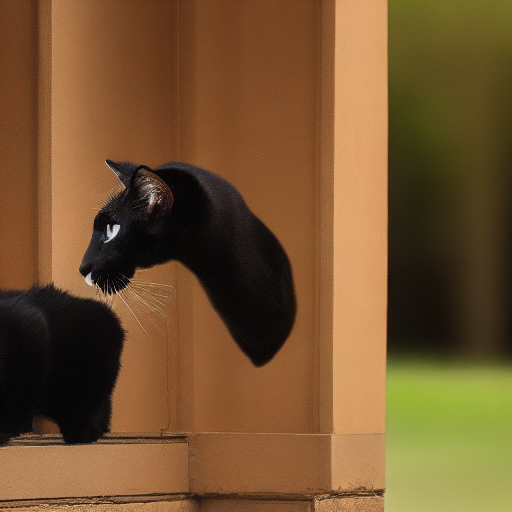

Saved: outputs/a_photo_of_a_black_cat_and_a_tiger_patchwise.png


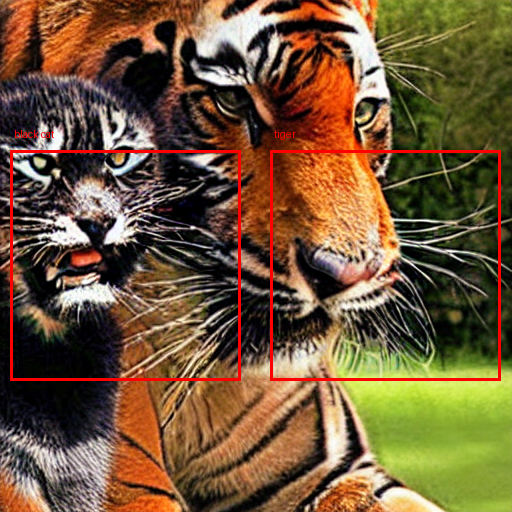

In [42]:
# patchwise_conditioned_sd_uncond_subtract.py
import torch
import torch.nn.functional as F
from diffusers import StableDiffusionPipeline
from PIL import Image, ImageDraw
import numpy as np
from tqdm import tqdm
import re
import os

# ---------- Config ----------
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

main_prompt = "a photo of a black cat and a tiger"
patch_prompts = ["black cat" ,"tiger"]  # must align with patches_image
height = 512
width = 512
num_inference_steps = 50
seed = 1 # 7
guidance_scale_main = 5.5
guidance_scale_patch = 5.5
do_cfg = True  # classifier-free guidance on

torch.manual_seed(seed)

# ---------- Load pipeline ----------
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype, use_safetensors=True)
pipe = pipe.to(device)
pipe.safety_checker = None

unet = pipe.unet
vae = pipe.vae
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
scheduler = pipe.scheduler

unet.eval()
vae.eval()
text_encoder.eval()

# ---------- Helper ----------
def sanitize_filename(s: str) -> str:
    return re.sub(r"[^a-zA-Z0-9]+", "_", s.strip()).strip("_").lower()

def ddpm_prev_sample_stateless(sample, noise_pred, t, alphas_cumprod):
    """Stateless DDPM posterior update to compute x_{t-1}."""
    t_index = int(t.item()) if isinstance(t, torch.Tensor) else int(t)
    device = sample.device
    dtype = sample.dtype

    alpha_bar_t = alphas_cumprod[t_index].to(device=device, dtype=dtype)
    alpha_bar_prev = alphas_cumprod[t_index - 1].to(device=device, dtype=dtype) if t_index > 0 else torch.tensor(1.0, device=device, dtype=dtype)
    alpha_t = alpha_bar_t / alpha_bar_prev
    beta_t = 1.0 - alpha_t

    sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)
    sqrt_alpha_bar_prev = torch.sqrt(alpha_bar_prev)
    sqrt_alpha_t = torch.sqrt(alpha_t)

    pred_x0 = (sample - sqrt_one_minus_alpha_bar_t * noise_pred) / (sqrt_alpha_bar_t + 1e-12)
    coef_x0 = (sqrt_alpha_bar_prev * beta_t) / (1.0 - alpha_bar_t + 1e-12)
    coef_xt = (sqrt_alpha_t * (1.0 - alpha_bar_prev)) / (1.0 - alpha_bar_t + 1e-12)
    mu = coef_x0 * pred_x0 + coef_xt * sample

    posterior_var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-12)
    posterior_var = posterior_var.clamp(min=1e-20)

    if t_index > 0:
        noise = torch.randn_like(sample)
        prev = mu + torch.sqrt(posterior_var) * noise
    else:
        prev = mu
    return prev

def make_embeddings(prompt, guidance_scale, do_cfg=True):
    text_inputs = tokenizer(prompt, padding="max_length", max_length=tokenizer.model_max_length,
                            truncation=True, return_tensors="pt").to(device)
    with torch.no_grad():
        text_embeddings = text_encoder(text_inputs.input_ids)[0]
    if do_cfg and guidance_scale > 1.0:
        uncond_input = tokenizer([""] * text_inputs.input_ids.shape[0],
                                 padding="max_length", max_length=tokenizer.model_max_length,
                                 return_tensors="pt").to(device)
        with torch.no_grad():
            uncond_embeddings = text_encoder(uncond_input.input_ids)[0]
        return torch.cat([uncond_embeddings, text_embeddings], dim=0)
    else:
        return text_embeddings

# ---------- Timesteps & latents ----------
scheduler.set_timesteps(num_inference_steps, device=device)
timesteps = scheduler.timesteps
alphas_cumprod = scheduler.alphas_cumprod.to(device)

init_noise_sigma = getattr(scheduler, "init_noise_sigma", 1.0)
batch_size = 1
num_channels_latents = unet.in_channels
latent_h = height // pipe.vae_scale_factor
latent_w = width // pipe.vae_scale_factor

try:
    extra_step_kwargs = pipe.prepare_extra_step_kwargs(generator=None, eta=0.0)
except Exception:
    extra_step_kwargs = {}

# ---------- Patches ----------
patches_image = [
    # Two large, square patches side by side
    # (x0, y0, x1, y1)
    (10,  150, 240, 380),   # patch 1
    (270, 150, 500, 380),   # patch 2
]
assert len(patch_prompts) == len(patches_image), "Number of patch prompts must equal number of patches"

def image_to_latent_coords(box, image_size=(width, height), latent_size=(latent_w, latent_h)):
    x0, y0, x1, y1 = box
    img_w, img_h = image_size
    l_w, l_h = latent_size
    lx0 = int(round(x0 * l_w / img_w))
    ly0 = int(round(y0 * l_h / img_h))
    lx1 = int(round(x1 * l_w / img_w))
    ly1 = int(round(y1 * l_h / img_h))
    lx0 = max(0, min(lx0, l_w-1))
    lx1 = max(0, min(max(lx1, lx0+1), l_w))
    ly0 = max(0, min(ly0, l_h-1))
    ly1 = max(0, min(max(ly1, ly0+1), l_h))
    return (lx0, ly0, lx1, ly1)

patches_latent = [image_to_latent_coords(b, (width, height), (latent_w, latent_h)) for b in patches_image]

# ---------- Embeddings ----------
main_emb_for_unet = make_embeddings(main_prompt, guidance_scale_main, do_cfg=do_cfg)
patch_embs_for_unet = [make_embeddings(p, guidance_scale_patch, do_cfg=do_cfg) for p in patch_prompts]

# ---------- Run one pass (helper) ----------
def run_denoising(latents, use_patches=True):
    with torch.no_grad():
        for i, t in enumerate(tqdm(timesteps)):
            latent_model_input = torch.cat([latents] * 2) if do_cfg else latents
            if hasattr(scheduler, "scale_model_input"):
                latent_model_input = scheduler.scale_model_input(latent_model_input, t)

            unet_out = unet(latent_model_input, timestep=t, encoder_hidden_states=main_emb_for_unet, return_dict=False)
            noise_pred_main = unet_out[0]
            if do_cfg:
                n_uncond, n_text = noise_pred_main.chunk(2)
                noise_pred_main = n_uncond + guidance_scale_main * (n_text - n_uncond)

            step_out = scheduler.step(noise_pred_main, t, latents, **extra_step_kwargs, return_dict=False)
            latents_prev = step_out[0].to(dtype=dtype)

            if use_patches:
                for (lx0, ly0, lx1, ly1), patch_emb in zip(patches_latent, patch_embs_for_unet):
                    patch = latents[:, :, ly0:ly1, lx0:lx1]
                    ph, pw = patch.shape[2:]
                    if ph <= 0 or pw <= 0: continue

                    patch_upsampled = F.interpolate(patch, size=(latent_h, latent_w), mode="bilinear", align_corners=False)
                    patch_input = torch.cat([patch_upsampled] * 2) if do_cfg else patch_upsampled
                    if hasattr(scheduler, "scale_model_input"):
                        patch_input_model = scheduler.scale_model_input(patch_input, t)
                    else:
                        patch_input_model = patch_input

                    unet_out_patch = unet(patch_input_model, timestep=t, encoder_hidden_states=patch_emb, return_dict=False)
                    noise_pred_patch_all = unet_out_patch[0]

                    if do_cfg:
                        p_uncond, p_text = noise_pred_patch_all.chunk(2)
                        noise_pred_patch_guided = p_uncond + guidance_scale_patch * (p_text - p_uncond)
                    else:
                        noise_pred_patch_guided = noise_pred_patch_all
                        p_uncond = None

                    patch_prev_full = ddpm_prev_sample_stateless(patch_upsampled, noise_pred_patch_guided, t, alphas_cumprod)

                    if do_cfg:
                        patch_prev_full_uncond = ddpm_prev_sample_stateless(patch_upsampled, p_uncond, t, alphas_cumprod)
                    else:
                        patch_prev_full_uncond = torch.zeros_like(patch_prev_full)

                    patch_prev_down = F.interpolate(patch_prev_full, size=(ph, pw), mode="bilinear", align_corners=False)
                    patch_prev_down_uncond = F.interpolate(patch_prev_full_uncond, size=(ph, pw), mode="bilinear", align_corners=False)

                    existing = latents_prev[:, :, ly0:ly1, lx0:lx1]
                    latents_prev[:, :, ly0:ly1, lx0:lx1] = existing + patch_prev_down - patch_prev_down_uncond

            latents = latents_prev
    return latents

# ---------- Run baseline and patchwise ----------
init_latents = torch.randn((batch_size, num_channels_latents, latent_h, latent_w),
                           device=device, dtype=dtype) * init_noise_sigma

latents_patch = run_denoising(init_latents.clone(), use_patches=True)
latents_base = run_denoising(init_latents.clone(), use_patches=False)

# ---------- Decode and save ----------
def decode_and_save(latents, filename, draw_patches=True):
    latents = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        image = vae.decode(latents).sample

    image = (image / 2 + 0.5).clamp(0, 1)
    image_np = (image.cpu().permute(0, 2, 3, 1).numpy() * 255).round().astype(np.uint8)[0]
    pil = Image.fromarray(image_np)

    if draw_patches:
        draw = ImageDraw.Draw(pil)
        # Try to load a font (optional, falls back to default if not found)

        for (box, label) in zip(patches_image, patch_prompts):
            x0, y0, x1, y1 = box
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            # Draw label slightly above top-left corner
            draw.text((x0 + 4, y0 - 22), label, fill="red")

    pil.save(filename)
    print("Saved:", filename)

    from IPython.display import display
    display(pil)

base_name = sanitize_filename(main_prompt)
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)

decode_and_save(latents_base, os.path.join(out_dir, f"{base_name}_baseline.png"), draw_patches=False)
decode_and_save(latents_patch, os.path.join(out_dir, f"{base_name}_patchwise.png"), draw_patches=True)
